In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd drive/MyDrive/data/behavior

/content/drive/MyDrive/data/behavior


In [4]:
!unzip archive.zip

Archive:  archive.zip
replace testing_sample.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
from sklearn.svm import OneClassSVM
import pandas as pd
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import numpy as np
from matplotlib import pyplot as plt
from numpy import quantile, where, random
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
%matplotlib inline

In [6]:
df = pd.read_csv('training_sample.csv')
print(df.shape)
df.head().T

(455401, 25)


,0,1,2,3,4
UserID,a720-6b732349-a720-4862-bd21-644732,a0c0-6b73247c-a0c0-4bd9-8baa-797356,86a8-6b735c67-86a8-407b-ba24-333055,6a3d-6b736346-6a3d-4085-934b-396834,b74a-6b737717-b74a-45c3-8c6a-421140
basket_icon_click,0,0,0,0,0
basket_add_list,0,0,0,0,1
basket_add_detail,0,0,0,0,0
sort_by,0,0,0,0,1
image_picker,0,0,0,0,0
account_page_click,0,0,0,0,0
promo_banner_click,0,0,0,0,0
detail_wishlist_add,0,0,0,0,0
list_size_dropdown,0,0,0,0,1


In [17]:
df4 = df[df.device_computer != 0]
df4.head().T
print(df4.shape)

(88448, 25)


In [47]:
df4.head().T

,6,11,19,22,24
UserID,7775-6b73b976-7775-4324-b1d9-622031,8976-6b747629-8976-4926-9cb2-715368,97c0-6b7645b3-97c0-4657-8ca8-978551,362d-6b7701e8-362d-4648-a171-128974,547b-6b773565-547b-4a8a-a7b6-309182
basket_icon_click,0,0,0,0,0
basket_add_list,0,0,0,0,0
basket_add_detail,0,0,0,0,0
sort_by,0,0,0,0,1
image_picker,0,0,0,0,0
account_page_click,0,0,0,0,0
promo_banner_click,0,0,0,0,0
detail_wishlist_add,0,0,0,0,0
list_size_dropdown,1,0,0,0,0


In [48]:
counts = df4["ordered"].value_counts()
print(counts)

0    82963
1     5485
Name: ordered, dtype: int64


In [39]:
df5 = df4[['basket_add_list' , 'basket_add_detail' , 'device_computer' , 'ordered' , 'saw_checkout' , 'basket_icon_click' , 'promo_banner_click']].copy()

In [7]:
# Create a new dataframe with two columns
df1 = df[['UserID' , 'basket_add_list' , 'basket_add_detail' , 'device_computer']].copy()
df1.head().T

,0,1,2,3,4
UserID,a720-6b732349-a720-4862-bd21-644732,a0c0-6b73247c-a0c0-4bd9-8baa-797356,86a8-6b735c67-86a8-407b-ba24-333055,6a3d-6b736346-6a3d-4085-934b-396834,b74a-6b737717-b74a-45c3-8c6a-421140
basket_add_list,0,0,0,0,1
basket_add_detail,0,0,0,0,0
device_computer,0,0,0,0,0


In [8]:
df2 = df1[df1.device_computer != 0]
df2.head().T
print(df2.shape)


(88448, 4)


In [9]:
df3 = df2.sample(1000, random_state=1).copy()

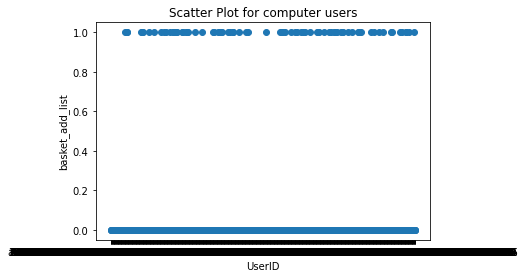

In [10]:
# Scatter plot with day against tip
plt.scatter(df3['UserID'], df3['basket_add_list'])
  
# Adding Title to the Plot
plt.title("Scatter Plot for computer users")
  
# Setting the X and Y labels
plt.xlabel('UserID')
plt.ylabel('basket_add_list')
  
plt.show()

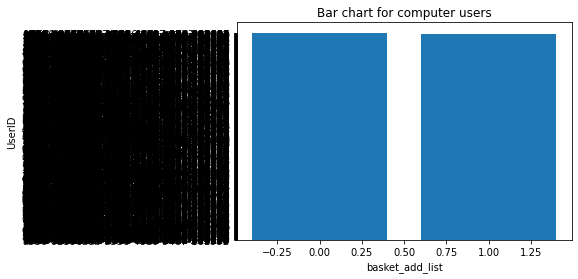

In [11]:
# Bar chart with day against tip
plt.bar(df3['basket_add_list'], df3['UserID'])
  
# Adding Title to the Plot
plt.title("Bar chart for computer users")
  
# Setting the X and Y labels
plt.xlabel('basket_add_list')
plt.ylabel('UserID')
  
# Adding the legends
plt.show()

In [12]:
pd.DataFrame(df3.UserID.unique()).values

array([['a556-0239cddb-a556-46d0-9467-161992'],
       ['2d94-d09c850c-2d94-4768-b69c-716228'],
       ['c793-16327d80-c793-b138-80av-374038'],
       ['980a-c34d5077-980a-462c-8b1b-322827'],
       ['1c47-614bd7b6-1c47-41b5-8d56-229526'],
       ['c2db-5d48cac1-c2db-4ca7-add0-274143'],
       ['6332-6180371e-6332-4026-93d8-704242'],
       ['5076-aa6077aa-5076-4b03-b62c-840100'],
       ['a926-61153ac5-a926-4567-9c43-821305'],
       ['21ab-42ab19d7-21ab-4849-9321-196853'],
       ['a473-41c231a1-a473-4768-b62d-777530'],
       ['4861-b75adb2c-4861-b186-8778-673786'],
       ['5700-70214775-5700-41b4-a9a7-894907'],
       ['52bb-6d147212-52bb-4787-a847-697412'],
       ['52b7-96aa6bd4-52b7-49c6-a90d-853386'],
       ['db40-5da7db13-db40-4c87-bcb7-46571'],
       ['c26b-6b1bab64-c26b-4141-a016-674720'],
       ['7d76-775377d7-7d76-438b-8c1a-956987'],
       ['8278-01642772-8278-4721-b374-220259'],
       ['95db-9a902ca4-95db-4d5a-a7a5-564523'],
       ['0768-307632ad-0768-4394-9736-803

In [13]:
item_counts = df3["UserID"].value_counts()
print(item_counts != 1)

a556-0239cddb-a556-46d0-9467-161992    False
1562-1e9174c9-1562-4674-846d-82151     False
193a-7838615a-193a-404d-860c-601072    False
6118-b9a171e9-6118-4a49-a173-658148    False
4906-3bb90d9a-4906-b1da-8078-948620    False
                                       ...  
5764-382bc942-5764-471b-84ad-492078    False
2a29-6474b371-2a29-4747-8b06-870421    False
4165-c1165273-4165-4874-bc6a-849176    False
289a-ba36796a-289a-45c7-a587-536505    False
dcb6-d3577650-dcb6-4331-bcd4-397681    False
Name: UserID, Length: 1000, dtype: bool


In [14]:
#Count duplicates
df3.UserID.duplicated().sum()

0

Text(0.5, 0, 'UserID')

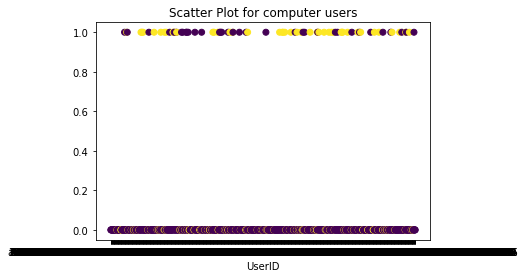

In [16]:
plt.scatter(df3['UserID'], df3['basket_add_list'], c=df3['basket_add_detail'])
  
# Adding Title to the Plot
plt.title("Scatter Plot for computer users")
  
# Setting the X and Y labels
plt.xlabel('UserID')

In [28]:
df5.head().T

,6,11,19,22,24
basket_add_list,0,0,0,0,0
basket_add_detail,0,0,0,0,0
device_computer,1,1,1,1,1
ordered,0,0,0,0,0
saw_checkout,0,0,0,0,0


In [68]:
df5['target'] = np.where(((df5['basket_icon_click'] == 0) & (df5['ordered'] == 1)), True, False)
df5.head()
#correct_dataset = df5.copy()

,basket_add_list,basket_add_detail,device_computer,ordered,saw_checkout,basket_icon_click,promo_banner_click,pro_target,icon_target,target
6,0,0,1,0,0,0,0,False,True,False
11,0,0,1,0,0,0,0,False,True,False
19,0,0,1,0,0,0,0,False,True,False
22,0,0,1,0,0,0,0,False,True,False
24,0,0,1,0,0,0,0,False,True,False


In [69]:
item_counts = df5["target"].value_counts()
print(item_counts)

False    86284
True      2164
Name: target, dtype: int64


In [64]:
(df5['basket_add_detail'] == 0) & (df5['basket_add_list'] == 0) & (df5['ordered'] ==1)

6         False
11        False
19        False
22        False
24        False
          ...  
455351    False
455352    False
455354    False
455371    False
455379    False
Length: 88448, dtype: bool

In [61]:
df5['icon_target'] = np.where(((df5['ordered'] == 0) & (df5['device_computer'] ==1)), True, False)
df5.head()

,basket_add_list,basket_add_detail,device_computer,ordered,saw_checkout,basket_icon_click,promo_banner_click,pro_target,icon_target
6,0,0,1,0,0,0,0,False,True
11,0,0,1,0,0,0,0,False,True
19,0,0,1,0,0,0,0,False,True
22,0,0,1,0,0,0,0,False,True
24,0,0,1,0,0,0,0,False,True


In [60]:
(df5['ordered'] == '0') & (df5['device_computer'] =='1')

6         False
11        False
19        False
22        False
24        False
          ...  
455351    False
455352    False
455354    False
455371    False
455379    False
Length: 88448, dtype: bool

In [ ]:
np.lo

In [41]:
df5['on_target'] = np.where(((df5['saw_checkout'] == 1) & (df5['promo_banner_click'] =='1')), True, False)
df5.head()

,basket_add_list,basket_add_detail,device_computer,ordered,saw_checkout,basket_icon_click,promo_banner_click,pro_target
6,0,0,1,0,0,0,0,False
11,0,0,1,0,0,0,0,False
19,0,0,1,0,0,0,0,False
22,0,0,1,0,0,0,0,False
24,0,0,1,0,0,0,0,False


In [53]:
item_counts = df5["icon_target"].value_counts()
print(item_counts)

False    88448
Name: icon_target, dtype: int64


In [34]:
df5.shape

(88448, 7)